In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from the repository root or from the Notebooks folder.
ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "house_prices_cleaned_featured.csv"
REPORTS_PATH = ROOT / "reports"

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Processed dataset:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the processed dataset at {DATA_PATH}. "
    )


Repository root: C:\Users\Hp\Desktop\K-LAB
Processed dataset: C:\Users\Hp\Desktop\K-LAB\data\processed\house_prices_cleaned_featured.csv


In [2]:
# Task 1: Load and Explore the Processed Dataset

# The dataset has already been cleaned, so this section only checks that it loaded correctly and inspects the columns needed for machine learning.


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()


Dataset shape: (4551, 24)

Columns:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country', 'city_listing_count', 'city_avg_price', 'city_median_price', 'city_avg_sqft_living', 'price_vs_city_avg', 'price_zscore']


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,street,city,statezip,country,city_listing_count,city_avg_price,city_median_price,city_avg_sqft_living,price_vs_city_avg,price_zscore
0,2014-05-02,313000.0,3,1.50,1340,7912,1.5,0,0,3,...,18810 Densmore Ave N,Shoreline,WA 98133,USA,123,420392.364047,360000.0,1774.837398,-1.073924e+05,-0.434332
1,2014-05-02,2384000.0,5,2.50,3650,9050,2.0,0,4,5,...,709 W Blaine St,Seattle,WA 98119,USA,1561,584294.898165,490000.0,1826.242793,1.799705e+06,3.238514
2,2014-05-02,342000.0,3,2.00,1930,11947,1.0,0,0,4,...,26206-26214 143rd Ave SE,Kent,WA 98042,USA,184,441880.990543,283600.0,1980.190217,-9.988099e+04,-0.382902
3,2014-05-02,420000.0,3,2.25,2000,8030,1.0,0,0,4,...,857 170th Pl NE,Bellevue,WA 98008,USA,281,862255.052017,725000.0,2673.113879,-4.422551e+05,-0.244571
4,2014-05-02,550000.0,4,2.50,1940,10500,1.0,0,0,4,...,9105 170th Ave NE,Redmond,WA 98052,USA,235,667649.534781,638000.0,2491.761702,-1.176495e+05,-0.014021


In [4]:
features = ["sqft_living", "yr_built"]
target = "price"

required_columns = features + [target]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

model_df = df[required_columns].copy()

print("Selected columns:")
print(model_df.head())

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nSummary statistics:")
model_df.describe()


Selected columns:
   sqft_living  yr_built      price
0         1340      1955   313000.0
1         3650      1921  2384000.0
2         1930      1966   342000.0
3         2000      1963   420000.0
4         1940      1976   550000.0

Missing values:
sqft_living    0
yr_built       0
price          0
dtype: int64

Summary statistics:


,sqft_living,yr_built,price
count,4551.000000,4551.000000,4.551000e+03
mean,2132.372226,1970.795649,5.579059e+05
std,955.949708,29.760073,5.639299e+05
min,370.000000,1900.000000,7.800000e+03
25%,1460.000000,1951.000000,3.262643e+05
50%,1970.000000,1976.000000,4.650000e+05
75%,2610.000000,1997.000000,6.575000e+05
max,13540.000000,2014.000000,2.659000e+07


In [5]:
# Task 2: Prepare Training and Testing Data

# The data is split into:

# - 80% training data — used to teach the models.
# - 20% testing data — used to evaluate predictions on unseen houses.

# The same split is used for both models.


In [6]:
# Remove any unexpected missing values only from the columns used here.
model_df = model_df.dropna().copy()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining features:")
X_train.head()


Training rows: 3640
Testing rows: 911

Training features:


,sqft_living,yr_built
4134,1360,1928
2098,2210,1969
3706,1200,1959
4055,2860,1990
2153,1760,1977


In [7]:
# Task 3: Build the Linear Regression Model

# Linear Regression fits a linear relationship between the selected house features and price.


In [8]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully.")

print("\nIntercept:")
print(linear_model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(features, linear_model.coef_):
    print(f"{feature}: {coefficient:,.2f}")


Linear Regression trained successfully.

Intercept:
4309665.059401468

Coefficients:
sqft_living: 281.99
yr_built: -2,207.80


In [9]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("LINEAR REGRESSION RESULTS")
print("-------------------------")
print(f"MAE:  ${linear_mae:,.2f}")
print(f"RMSE: ${linear_rmse:,.2f}")
print(f"R²:   {linear_r2:.4f}")


LINEAR REGRESSION RESULTS
-------------------------
MAE:  $174,187.08
RMSE: $262,034.53
R²:   0.5385


In [10]:
# Task 4: Build the Random Forest Model

# Random Forest combines many decision trees. It can capture more complex and non-linear relationships than Linear Regression.


In [11]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

forest_predictions = random_forest_model.predict(
    X_test
)

print("Random Forest trained successfully.")


Random Forest trained successfully.


In [12]:
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("RANDOM FOREST RESULTS")
print("---------------------")
print(f"MAE:  ${forest_mae:,.2f}")
print(f"RMSE: ${forest_rmse:,.2f}")
print(f"R²:   {forest_r2:.4f}")


RANDOM FOREST RESULTS
---------------------
MAE:  $187,640.23
RMSE: $297,656.88
R²:   0.4045


In [13]:
# Task 5: Compare Linear Regression and Random Forest

# For the comparison:

# - Lower MAE is better
# - Lower RMSE is better
# - Higher R² is better


In [14]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        forest_rmse
    ],
    "R2": [
        linear_r2,
        forest_r2
    ]
})

results.round(4)


,Model,MAE,RMSE,R2
0,Linear Regression,174187.0808,262034.5264,0.5385
1,Random Forest,187640.2317,297656.8835,0.4045


In [15]:
best_model_row = results.loc[
    results["RMSE"].idxmin()
]

best_model = best_model_row["Model"]

print("MODEL COMPARISON")
print("----------------")

print(
    f"Best model based on the lowest RMSE: "
    f"{best_model}"
)

print(
    f"\nLinear Regression RMSE: "
    f"${linear_rmse:,.2f}"
)

print(
    f"Random Forest RMSE: "
    f"${forest_rmse:,.2f}"
)

print(
    f"\nLinear Regression R²: "
    f"{linear_r2:.4f}"
)

print(
    f"Random Forest R²: "
    f"{forest_r2:.4f}"
)


MODEL COMPARISON
----------------
Best model based on the lowest RMSE: Linear Regression

Linear Regression RMSE: $262,034.53
Random Forest RMSE: $297,656.88

Linear Regression R²: 0.5385
Random Forest R²: 0.4045


In [16]:
# Task 6: Visualize the Predictions

# The first chart compares actual house prices with each model's predictions. Predictions closer to the diagonal line are more accurate.


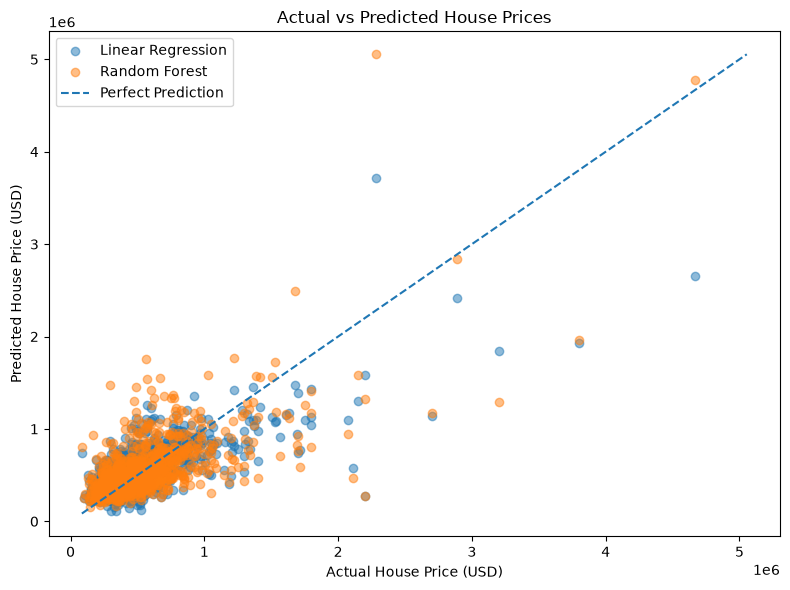

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5,
    label="Linear Regression"
)

plt.scatter(
    y_test,
    forest_predictions,
    alpha=0.5,
    label="Random Forest"
)

min_price = min(
    y_test.min(),
    linear_predictions.min(),
    forest_predictions.min()
)

max_price = max(
    y_test.max(),
    linear_predictions.max(),
    forest_predictions.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price (USD)")
plt.ylabel("Predicted House Price (USD)")
plt.title("Actual vs Predicted House Prices")
plt.legend()

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "a3_actual_vs_predicted.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


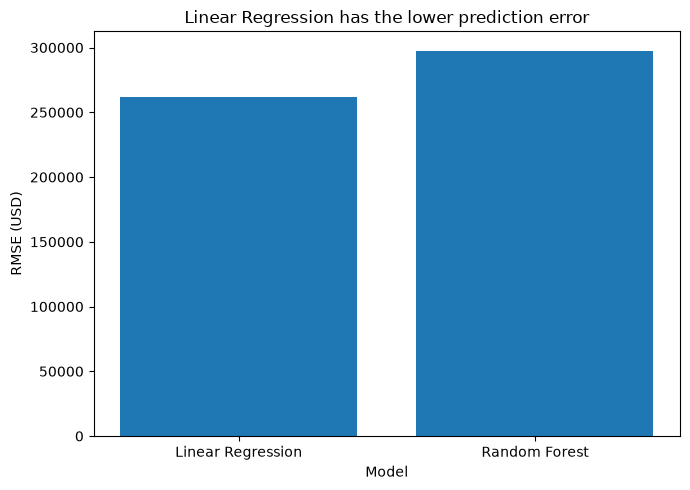

In [18]:
plt.figure(figsize=(7, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.ylabel("RMSE (USD)")
plt.xlabel("Model")
plt.title(
    f"{best_model} has the lower prediction error"
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "a3_model_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [19]:
# Task 7: Final Conclusion

# Run the cell below after training both models. It creates a conclusion using the actual model results.


In [20]:
if forest_rmse < linear_rmse:
    conclusion = (
        "Random Forest is the model I would trust more for this dataset. "
        f"It achieved a lower RMSE (${forest_rmse:,.2f}) than Linear Regression "
        f"(${linear_rmse:,.2f}) and an R² of {forest_r2:.4f} compared with "
        f"{linear_r2:.4f} for Linear Regression. "
        "This suggests that the relationship between living area, year built, "
        "and house price is not completely linear. Random Forest can model "
        "non-linear patterns and interactions between the features."
    )
else:
    conclusion = (
        "Linear Regression is the model I would trust more for this dataset. "
        f"It achieved a lower RMSE (${linear_rmse:,.2f}) than Random Forest "
        f"(${forest_rmse:,.2f}) and an R² of {linear_r2:.4f} compared with "
        f"{forest_r2:.4f} for Random Forest. "
        "With only these two features, the simpler linear relationship generalized "
        "better to the test data."
    )

print(conclusion)


Linear Regression is the model I would trust more for this dataset. It achieved a lower RMSE ($262,034.53) than Random Forest ($297,656.88) and an R² of 0.5385 compared with 0.4045 for Random Forest. With only these two features, the simpler linear relationship generalized better to the test data.


In [21]:
# Final Notes

# This assignment uses only `sqft_living` and `yr_built` so both models are evaluated on exactly the same information.

# The processed dataset contains additional engineered columns from Assignment 2. Columns derived from the target price were deliberately excluded to avoid data leakage.
